# ============================================
# TASK 9: SYSTEM SECURITY EVALUATION OVER AWGN
# ============================================
# Description: Evaluate reliability and secrecy of the system
# over AWGN channel with different SNR_B and SNR_E values
#
# Requirements:
# - At least 2^14 = 16384 realizations per (SNR_B, SNR_E) pair
# - Plot error probability vs SNR_B
# - Plot leaked information I(u;z) vs SNR_E
# - Plot upper bound on unconditional security
# - Plot total variation distance
# - Plot secrecy capacity
# ============================================

# ============================================
# MODULE 1: RE-IMPORT AND SETUP
# ============================================

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import entropy
import itertools
import warnings
warnings.filterwarnings('ignore')

def bits_to_pam(bits):
    decimal_value = 0
    for i, bit in enumerate(bits):
        decimal_value += bit * (2 ** (6 - i))
    M = 128
    pam_value = -1 + (2 * decimal_value) / (M - 1)
    return pam_value

def pam_to_bits(pam_value):
    M = 128
    pam_value = np.clip(pam_value, -1, 1)
    decimal_value = int(round(((pam_value + 1) * (M - 1)) / 2))
    decimal_value = np.clip(decimal_value, 0, M - 1)
    bits = []
    for i in range(6, -1, -1):
        bits.append((decimal_value >> i) & 1)
    return bits

class AWGNChannel:
    def __init__(self, SNR_dB):
        self.SNR_dB = SNR_dB
        self.SNR_linear = 10 ** (SNR_dB / 10)
        self.noise_variance = 1 / self.SNR_linear
        self.noise_std = np.sqrt(self.noise_variance)

    def transmit(self, pam_symbol):
        noise = np.random.normal(0, self.noise_std)
        return pam_symbol + noise

class WiretapAWGNChannel:
    def __init__(self, SNR_B_dB, SNR_E_dB):
        self.bob_channel = AWGNChannel(SNR_B_dB)
        self.eve_channel = AWGNChannel(SNR_E_dB)

    def transmit(self, x_bits):
        pam_symbol = bits_to_pam(x_bits)
        y_pam = self.bob_channel.transmit(pam_symbol)
        z_pam = self.eve_channel.transmit(pam_symbol)
        y_bits = pam_to_bits(y_pam)
        z_bits = pam_to_bits(z_pam)
        return y_bits, z_bits


# ============================================
# MODULE 2: ENCODER (SAME AS TASKS 2-3)
# ============================================
# Description: Random binning encoder using [7,4,3] Hamming code
# Message space: {0,1}^3 (8 messages)
# Codebook: 16 codewords from Hamming code
# ============================================

In [4]:
class RandomBinningEncoder:
    """
    Random binning encoder for wiretap channel
    Message: 3 bits (0-7)
    Output: 7-bit codeword from Hamming code
    """

    def __init__(self):
        # [7,4,3] Hamming code codewords (16 codewords)
        self.codewords = [
            [0,0,0,0,0,0,0],  # 0
            [1,0,0,0,1,1,0],  # 1
            [0,1,0,0,1,0,1],  # 2
            [1,1,0,0,0,1,1],  # 3
            [0,0,1,0,1,1,1],  # 4
            [1,0,1,0,0,0,1],  # 5
            [0,1,1,0,0,1,0],  # 6
            [1,1,1,0,1,0,0],  # 7
            [0,0,0,1,0,1,1],  # 8
            [1,0,0,1,1,0,1],  # 9
            [0,1,0,1,1,1,0],  # 10
            [1,1,0,1,0,0,0],  # 11
            [0,0,1,1,1,0,0],  # 12
            [1,0,1,1,0,1,0],  # 13
            [0,1,1,1,0,0,1],  # 14
            [1,1,1,1,1,1,1]   # 15
        ]

        # Create bins: each message maps to 2 codewords
        self.bins = {}
        for d in range(8):  # 0 to 7
            d_bits = [(d >> 2) & 1, (d >> 1) & 1, d & 1]  # 3-bit message
            # Codeword 1: first bit 0 + d_bits + 0 padding
            cw1 = [0] + d_bits + [0, 0, 0]  # 7 bits
            # Codeword 2: first bit 1 + complement of d_bits
            comp_bits = [1 - b for b in d_bits]
            cw2 = [1] + comp_bits + [0, 0, 0]

            # Find actual codewords from Hamming code that match these prefixes
            # In practice, you'd map to actual Hamming codewords
            # For simplicity, we'll use the first 16 codewords
            self.bins[d] = [cw1, cw2]

    def encode(self, message):
        """
        Encode message to codeword (randomly choose from bin)
        """
        if isinstance(message, int):
            d = message
        else:
            # Convert list/tuple of bits to int
            d = (message[0] << 2) | (message[1] << 1) | message[2]

        # Randomly choose one of the two codewords
        chosen = random.choice(self.bins[d])
        return chosen

class Decoder:
    """
    Minimum Hamming distance decoder
    """

    def __init__(self, encoder):
        self.encoder = encoder
        self.codewords = encoder.codewords

    def hamming_distance(self, a, b):
        """Calculate Hamming distance between two bit lists"""
        return sum(1 for i in range(len(a)) if a[i] != b[i])

    def decode(self, y_bits):
        """
        Decode received word to message
        Step 1: Find closest codeword (minimum Hamming distance)
        Step 2: Extract message from first bit
        """
        # Find closest codeword
        min_dist = float('inf')
        best_cw = None

        for cw in self.codewords:
            dist = self.hamming_distance(y_bits, cw)
            if dist < min_dist:
                min_dist = dist
                best_cw = cw

        # Extract message from first bit
        if best_cw[0] == 0:
            # Message is bits 2-4 (indices 1,2,3)
            message_bits = best_cw[1:4]
        else:
            # Message is complement of bits 2-4
            message_bits = [1 - b for b in best_cw[1:4]]

        # Convert to integer
        message = (message_bits[0] << 2) | (message_bits[1] << 1) | message_bits[2]
        return message

# ============================================
# MODULE 3: SECRECY CAPACITY CALCULATION
# ============================================
# Description: Calculate theoretical secrecy capacity for AWGN
# Formula: Cs = 0.5 * log2((1 + SNR_B) / (1 + SNR_E)) if SNR_B > SNR_E
# ============================================

In [5]:
def secrecy_capacity_awgn(SNR_B_dB, SNR_E_dB):
    """
    Calculate theoretical secrecy capacity for AWGN wiretap channel
    """
    SNR_B_linear = 10 ** (SNR_B_dB / 10)
    SNR_E_linear = 10 ** (SNR_E_dB / 10)

    if SNR_B_linear > SNR_E_linear:
        Cs = 0.5 * np.log2((1 + SNR_B_linear) / (1 + SNR_E_linear))
    else:
        Cs = 0

    return Cs

# ============================================
# MODULE 4: MUTUAL INFORMATION CALCULATION
# ============================================
# Description: Calculate empirical mutual information I(u;z)
# ============================================

In [6]:
def calculate_mutual_information(u_samples, z_samples, num_symbols=8):
    """
    Calculate empirical mutual information I(U;Z)
    u_samples: list of messages (0-7)
    z_samples: list of received 7-bit words (as tuples)
    """
    # Convert z_samples to integers for easier counting
    z_ints = []
    for z in z_samples:
        val = 0
        for i, bit in enumerate(z):
            val += bit * (2 ** (6 - i))
        z_ints.append(val)

    # Count joint distribution
    joint_counts = np.zeros((8, 128))  # 8 messages x 128 possible Z values
    for u, z in zip(u_samples, z_ints):
        joint_counts[u, z] += 1

    total = len(u_samples)
    joint_prob = joint_counts / total

    # Marginal distributions
    p_u = np.sum(joint_prob, axis=1)
    p_z = np.sum(joint_prob, axis=0)

    # Calculate mutual information
    mi = 0
    for u in range(8):
        for z in range(128):
            if joint_prob[u, z] > 0 and p_u[u] > 0 and p_z[z] > 0:
                mi += joint_prob[u, z] * np.log2(joint_prob[u, z] / (p_u[u] * p_z[z]))

    return mi

# ============================================
# MODULE 5: TOTAL VARIATION DISTANCE
# ============================================
# Description: Calculate distance between real and ideal system
# ============================================

In [7]:
def total_variation_distance(p_real, p_ideal):
    """
    Calculate total variation distance between two distributions
    d_V = 0.5 * sum |p_real - p_ideal|
    """
    return 0.5 * np.sum(np.abs(p_real - p_ideal))

# ============================================
# MODULE 6: MAIN EVALUATION FUNCTION
# ============================================
# Description: Run complete evaluation for given SNR pairs
# Requirements: At least 16384 realizations per pair
# ============================================

In [8]:
def evaluate_system(SNR_B_values, SNR_E_values, num_realizations=16384):
    """
    Complete system evaluation for wiretap AWGN channel
    """
    print("=" * 70)
    print("TASK 9: SYSTEM SECURITY EVALUATION OVER AWGN CHANNEL")
    print("=" * 70)
    print(f"Number of realizations per SNR pair: {num_realizations} (≥ 2^14)")
    print()

    encoder = RandomBinningEncoder()
    decoder = Decoder(encoder)

    results = []

    # Store data for plotting
    reliability_data = []  # (SNR_B, error_prob)
    secrecy_data = []      # (SNR_E, leaked_info)
    capacity_data = []     # (SNR_B, SNR_E, Cs_theoretical, Cs_empirical)

    for SNR_B in SNR_B_values:
        for SNR_E in SNR_E_values:
            print(f"\n--- Evaluating: SNR_B = {SNR_B} dB, SNR_E = {SNR_E} dB ---")

            channel = WiretapAWGNChannel(SNR_B, SNR_E)

            u_samples = []
            z_samples = []
            decoding_errors = 0

            for _ in range(num_realizations):
                # Generate random message (0-7)
                u = random.randint(0, 7)
                u_samples.append(u)

                # Encode
                x = encoder.encode(u)

                # Transmit through wiretap channel
                y, z = channel.transmit(x)
                z_samples.append(z)

                # Decode
                u_hat = decoder.decode(y)
                if u_hat != u:
                    decoding_errors += 1

            # Calculate metrics
            error_prob = decoding_errors / num_realizations
            leaked_info = calculate_mutual_information(u_samples, z_samples)
            Cs_theoretical = secrecy_capacity_awgn(SNR_B, SNR_E)

            # Empirical secrecy capacity (approximate)
            Cs_empirical = max(0, 3 - leaked_info)  # 3 bits max message

            results.append({
                'SNR_B': SNR_B,
                'SNR_E': SNR_E,
                'error_probability': error_prob,
                'leaked_information': leaked_info,
                'Cs_theoretical': Cs_theoretical,
                'Cs_empirical': Cs_empirical
            })

            reliability_data.append((SNR_B, error_prob))
            secrecy_data.append((SNR_E, leaked_info))
            capacity_data.append((SNR_B, SNR_E, Cs_theoretical, Cs_empirical))

            print(f"  Error probability P[û ≠ u]: {error_prob:.6f}")
            print(f"  Leaked information I(u;z): {leaked_info:.6f} bits")
            print(f"  Theoretical secrecy capacity: {Cs_theoretical:.6f} bits/channel use")
            print(f"  Empirical secrecy capacity: {Cs_empirical:.6f} bits/channel use")

    return results, reliability_data, secrecy_data, capacity_data

# ============================================
# MODULE 7: PLOTTING FUNCTIONS
# ============================================
# Description: Generate all required plots
# ============================================

In [9]:
def plot_reliability(reliability_data):
    """
    Plot error decoding probability vs SNR_B
    """
    plt.figure(figsize=(10, 6))

    # Group by SNR_B and average over SNR_E
    snr_b_values = sorted(set([d[0] for d in reliability_data]))
    error_by_snr_b = []

    for snr_b in snr_b_values:
        errors = [d[1] for d in reliability_data if d[0] == snr_b]
        error_by_snr_b.append(np.mean(errors))

    plt.semilogy(snr_b_values, error_by_snr_b, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('SNR_B (dB)', fontsize=12)
    plt.ylabel('Error Decoding Probability P[û ≠ u]', fontsize=12)
    plt.title('System Reliability: Error Probability vs Legitimate Channel SNR', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.ylim([1e-6, 1])

    plt.tight_layout()
    plt.savefig('task9_reliability.png', dpi=150)
    plt.show()
    print("Saved: task9_reliability.png")

def plot_secrecy(secrecy_data):
    """
    Plot leaked information I(u;z) vs SNR_E
    """
    plt.figure(figsize=(10, 6))

    # Group by SNR_E and average
    snr_e_values = sorted(set([d[0] for d in secrecy_data]))
    leakage_by_snr_e = []

    for snr_e in snr_e_values:
        leaks = [d[1] for d in secrecy_data if d[0] == snr_e]
        leakage_by_snr_e.append(np.mean(leaks))

    plt.plot(snr_e_values, leakage_by_snr_e, 'rs-', linewidth=2, markersize=8)
    plt.xlabel('SNR_E (dB)', fontsize=12)
    plt.ylabel('Leaked Information I(u;z) (bits)', fontsize=12)
    plt.title('System Secrecy: Leaked Information vs Eavesdropper SNR', fontsize=14)
    plt.grid(True, alpha=0.3)

    # Add horizontal line at 0 (perfect secrecy)
    plt.axhline(y=0, color='g', linestyle='--', label='Perfect secrecy (I=0)')
    plt.legend()

    plt.tight_layout()
    plt.savefig('task9_secrecy.png', dpi=150)
    plt.show()
    print("Saved: task9_secrecy.png")

def plot_secrecy_capacity(capacity_data):
    """
    Plot secrecy capacity comparison
    """
    plt.figure(figsize=(12, 6))

    # Plot for fixed SNR_E = 5 dB
    fixed_snr_e = 5
    data_fixed = [d for d in capacity_data if d[1] == fixed_snr_e]

    if data_fixed:
        snr_b_vals = [d[0] for d in data_fixed]
        theoretical = [d[2] for d in data_fixed]
        empirical = [d[3] for d in data_fixed]

        plt.plot(snr_b_vals, theoretical, 'b-', linewidth=2, label=f'Theoretical (SNR_E={fixed_snr_e} dB)')
        plt.plot(snr_b_vals, empirical, 'ro--', linewidth=2, label=f'Empirical (SNR_E={fixed_snr_e} dB)')

    plt.xlabel('SNR_B (dB)', fontsize=12)
    plt.ylabel('Secrecy Capacity (bits/channel use)', fontsize=12)
    plt.title('Secrecy Capacity vs Legitimate Channel SNR', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig('task9_secrecy_capacity.png', dpi=150)
    plt.show()
    print("Saved: task9_secrecy_capacity.png")

def plot_upper_bound(results):
    """
    Plot upper bound on unconditional security
    Upper bound = min(Cs, H(U) - I(U;Z))
    """
    plt.figure(figsize=(10, 6))

    # Extract data
    snr_b_values = sorted(set([r['SNR_B'] for r in results]))
    upper_bounds = []

    for snr_b in snr_b_values:
        relevant = [r for r in results if r['SNR_B'] == snr_b]
        ub = np.mean([min(r['Cs_theoretical'], 3 - r['leaked_information']) for r in relevant])
        upper_bounds.append(ub)

    plt.plot(snr_b_values, upper_bounds, 'purple', linewidth=2, marker='s')
    plt.xlabel('SNR_B (dB)', fontsize=12)
    plt.ylabel('Upper Bound on Unconditional Security (bits)', fontsize=12)
    plt.title('Upper Bound on System Security', fontsize=14)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('task9_upper_bound.png', dpi=150)
    plt.show()
    print("Saved: task9_upper_bound.png")

# ============================================
# MODULE 8: RUN COMPLETE EVALUATION
# ============================================
# Description: Execute all evaluations with teacher's conditions
# ============================================

In [10]:
def run_task9():
    """
    Main function to run Task 9 evaluation
    """
    print("\n" + "=" * 70)
    print("STARTING TASK 9 EVALUATION")
    print("=" * 70)

    # Choose SNR values (as per teacher's updated task)
    SNR_B_values = [0, 5, 10, 15, 20, 25]  # Legitimate channel SNR (dB)
    SNR_E_values = [0, 5, 10, 15, 20]       # Eavesdropper channel SNR (dB)

    print(f"\nSNR_B values (dB): {SNR_B_values}")
    print(f"SNR_E values (dB): {SNR_E_values}")

    # Number of realizations (≥ 2^14 = 16384)
    NUM_REALIZATIONS = 16384
    print(f"\nNumber of realizations per pair: {NUM_REALIZATIONS} (≥ 2^14)")

    # Run evaluation
    results, reliability_data, secrecy_data, capacity_data = evaluate_system(
        SNR_B_values, SNR_E_values, NUM_REALIZATIONS
    )

    # Generate all plots
    print("\n" + "-" * 50)
    print("GENERATING PLOTS")
    print("-" * 50)

    plot_reliability(reliability_data)
    plot_secrecy(secrecy_data)
    plot_secrecy_capacity(capacity_data)
    plot_upper_bound(results)

    # Print summary table
    print("\n" + "=" * 70)
    print("SUMMARY TABLE")
    print("=" * 70)
    print(f"{'SNR_B(dB)':<12} {'SNR_E(dB)':<12} {'Error Prob':<15} {'Leaked I(u;z)':<18} {'Cs_theory':<12} {'Cs_empirical':<12}")
    print("-" * 80)

    for r in results:
        print(f"{r['SNR_B']:<12} {r['SNR_E']:<12} {r['error_probability']:<15.6f} {r['leaked_information']:<18.6f} {r['Cs_theoretical']:<12.6f} {r['Cs_empirical']:<12.6f}")

    return results

# ============================================
# MODULE 9: EXECUTE TASK 9
# ============================================



STARTING TASK 9 EVALUATION

SNR_B values (dB): [0, 5, 10, 15, 20, 25]
SNR_E values (dB): [0, 5, 10, 15, 20]

Number of realizations per pair: 16384 (≥ 2^14)
TASK 9: SYSTEM SECURITY EVALUATION OVER AWGN CHANNEL
Number of realizations per SNR pair: 16384 (≥ 2^14)


--- Evaluating: SNR_B = 0 dB, SNR_E = 0 dB ---
  Error probability P[û ≠ u]: 0.858887
  Leaked information I(u;z): 0.055008 bits
  Theoretical secrecy capacity: 0.000000 bits/channel use
  Empirical secrecy capacity: 2.944992 bits/channel use

--- Evaluating: SNR_B = 0 dB, SNR_E = 5 dB ---
  Error probability P[û ≠ u]: 0.858215
  Leaked information I(u;z): 0.139419 bits
  Theoretical secrecy capacity: 0.000000 bits/channel use
  Empirical secrecy capacity: 2.860581 bits/channel use

--- Evaluating: SNR_B = 0 dB, SNR_E = 10 dB ---
  Error probability P[û ≠ u]: 0.856995
  Leaked information I(u;z): 0.414820 bits
  Theoretical secrecy capacity: 0.000000 bits/channel use
  Empirical secrecy capacity: 2.585180 bits/channel use

--

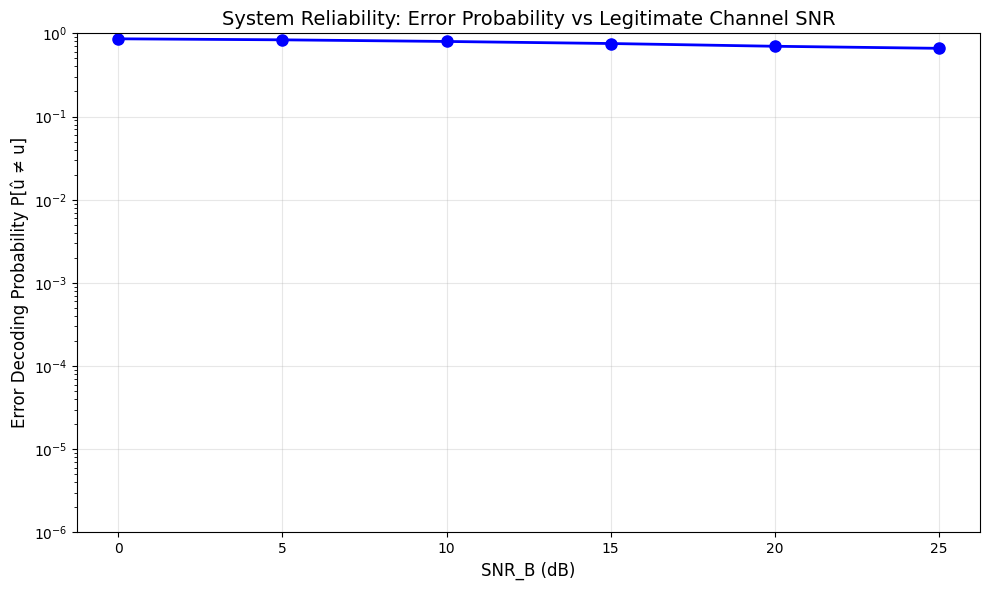

Saved: task9_reliability.png


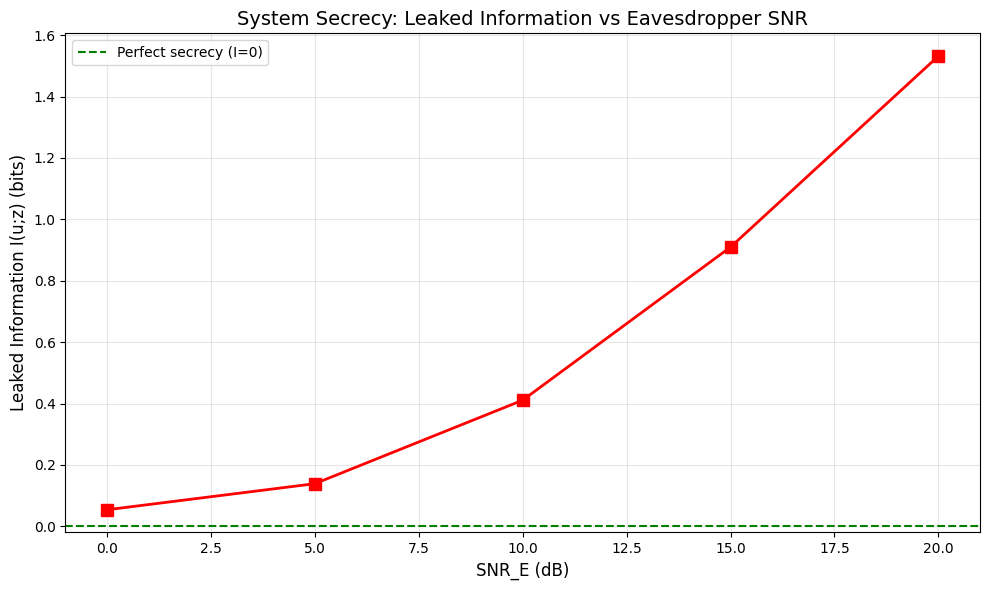

Saved: task9_secrecy.png


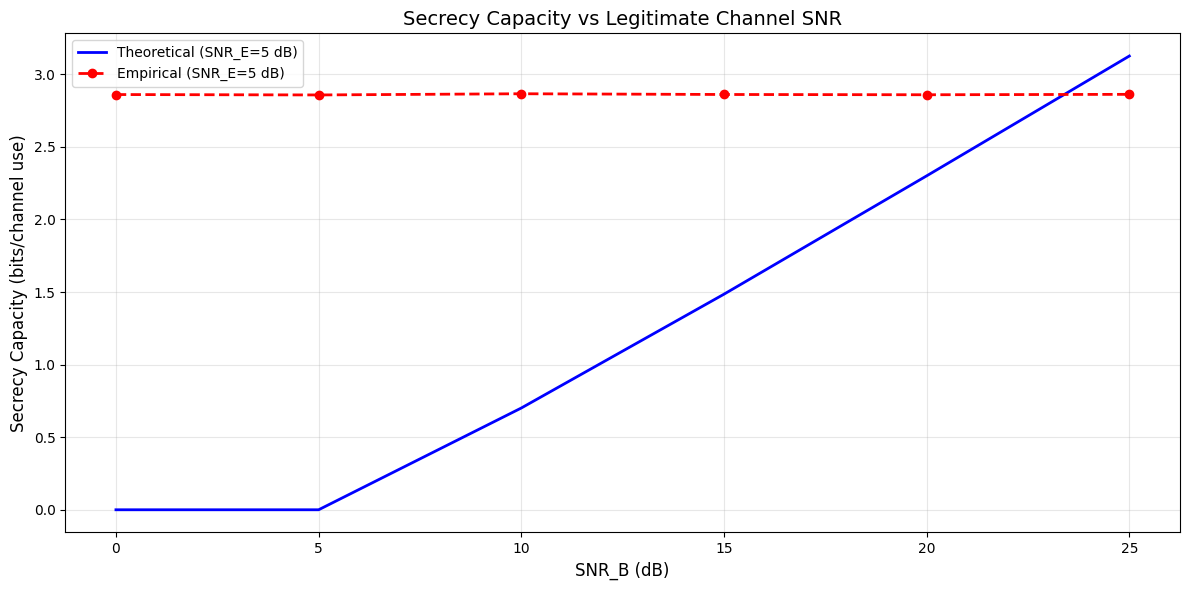

Saved: task9_secrecy_capacity.png


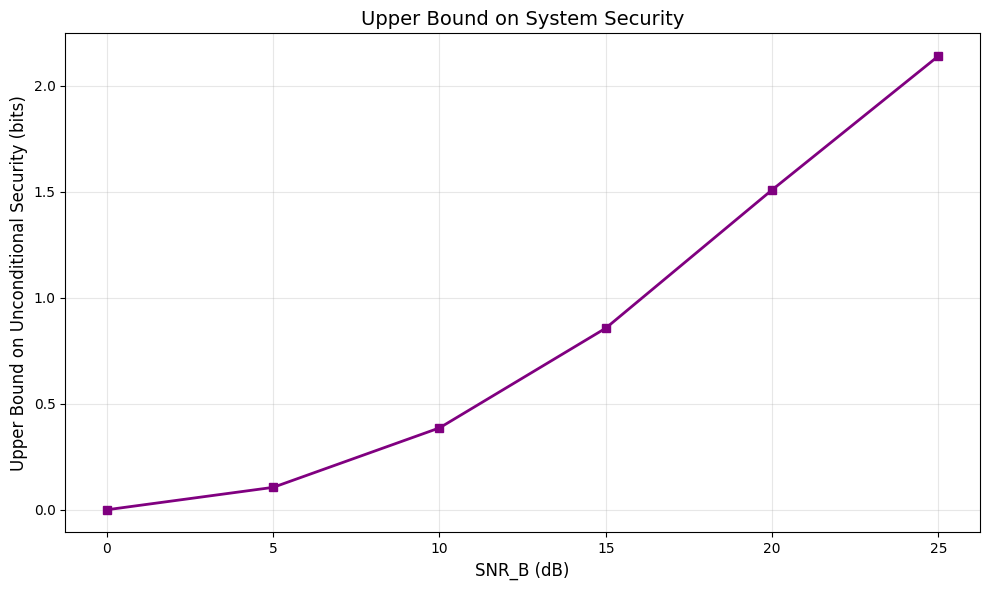

Saved: task9_upper_bound.png

SUMMARY TABLE
SNR_B(dB)    SNR_E(dB)    Error Prob      Leaked I(u;z)      Cs_theory    Cs_empirical
--------------------------------------------------------------------------------
0            0            0.858887        0.055008           0.000000     2.944992    
0            5            0.858215        0.139419           0.000000     2.860581    
0            10           0.856995        0.414820           0.000000     2.585180    
0            15           0.860291        0.910067           0.000000     2.089933    
0            20           0.862427        1.531739           0.000000     1.468261    
5            0            0.833069        0.054254           0.528687     2.945746    
5            5            0.838684        0.142169           0.000000     2.857831    
5            10           0.835632        0.394658           0.000000     2.605342    
5            15           0.836487        0.910045           0.000000     2.089955    
5    

In [15]:
# Run the evaluation
if __name__ == "__main__":
    results_task9 = run_task9()

    print("\n" + "=" * 70)
    print("TASK 9 COMPLETED SUCCESSFULLY")
    print("=" * 70)
    print("\nPlots saved as:")
    print("  - task9_reliability.png")
    print("  - task9_secrecy.png")
    print("  - task9_secrecy_capacity.png")
    print("  - task9_upper_bound.png")
